# Modelagem Preditiva de Machine Learning
- **Projeto:** Delivery Analytics (Previsão de Atrasos Logísticos)
---
### Objetivo
Transição da etapa de inferência estatística (por que atrasa?) para a etapa preditiva (quantos minutos vai atrasar?). O objetivo é prever o **Atraso em Minutos (`atraso_min`)** no momento em que o pedido é feito, utilizando as informações disponíveis na origem: Distância (`km`), SLA prometido (`sla_min`), `turno`, `modalidade`, `canal` e a presença de dinâmica (`evento_flag`).

In [16]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import randint
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate, ShuffleSplit, GridSearchCV
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [17]:
df = pd.read_csv("../data/processed/base_tratada.csv")

# Selecionando apenas os pedidos que não foram cancelados ou com insucesso
df_ml = df[df['status'] == 'Finalizada'].copy()

# Features disponíveis ANTES da entrega acontecer
features = ['km', 'sla_min', 'turno', 'modalidade', 'canal', 'evento_flag']
target = 'atraso_min'

df_ml = df_ml[features + [target]].dropna()

print(f"Base de Treinamento pronta com {len(df_ml)} entregas finalizadas.")

Base de Treinamento pronta com 12176 entregas finalizadas.


In [18]:
# Separando variáveis por tipo
continuous_variables = ['km', 'sla_min']
nominal_variables = ['turno', 'modalidade', 'canal']
passthrough_variables = ['evento_flag'] # Já é 0 ou 1

# 1. Pipeline para variáveis contínuas (RobustScaler para lidar com outliers de KM)
continuous_preprocessing = Pipeline(steps=[
    ("normalization", RobustScaler())
])

# 2. Pipeline para variáveis nominais (OneHotEncoder para categorias)
nominal_preprocessing = Pipeline(steps=[
    ("encoding", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Consolidação no ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('continuous', continuous_preprocessing, continuous_variables),
        ('nominal', nominal_preprocessing, nominal_variables),
        ('passthrough', 'passthrough', passthrough_variables)
    ],
    remainder='drop' 
)

In [19]:
# Definição dos Modelos e Grades de Hiperparâmetros

modelos = [
    {
        "nome": "DUM",
        "objeto": DummyRegressor(strategy='mean'),
        "hp": {}
    },
    {
        "nome": "LRG",
        "objeto": LinearRegression(),
        "hp": {}
    },
    {
        "nome": "KNN",
        "objeto": KNeighborsRegressor(),
        "hp": {
            'regressor__n_neighbors': np.arange(5, 51, 2),
            'regressor__weights': ['uniform', 'distance'],
            'regressor__p': [1, 2]
        }
    },
    {
        "nome": "RFR",
        "objeto": RandomForestRegressor(random_state=42, n_jobs=-1),
        "hp": {
            'regressor__n_estimators': [100, 200, 300], 
            'regressor__max_depth': [None, 10, 20], 
            'regressor__min_samples_split': [2, 5, 10], 
            'regressor__min_samples_leaf': [1, 2, 4], 
            'regressor__max_features': ['sqrt', 'log2', None] 
        }
    },
    {
        "nome": "XGB",
        "objeto": XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'),
        "hp": {
            'regressor__n_estimators': [100, 200, 300, 500], # Quantidade de árvores 
            'regressor__max_depth': [3, 5, 7, 10], 
            'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2], # Taxa de aprendizado (evittar overfitting)
            'regressor__subsample': [0.6, 0.8, 1.0], 
            'regressor__colsample_bytree': [0.6, 0.8, 1.0] 
        }
    }
]

print("Grade de modelos carregada com sucesso!")

Grade de modelos carregada com sucesso!


In [20]:
# Execução do Nested Cross-Validation

outer_cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
metrics = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

X = df_ml[features]
y = df_ml[target]
results_list = []

for model_info in modelos:
    nome = model_info['nome']
    print(f"Iniciando Nested CV para o modelo: {nome}...")

    # Pipeline: preprocessor + modelo
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model_info['objeto'])
    ])

    # Utilizando RandomizedSearchCV no Loop Interno
    if model_info['hp']:
        estimator_to_cv = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=model_info['hp'],
            n_iter=15, # Número de combinações aleatórias a testar
            cv=3,
            scoring='neg_mean_absolute_error',
            random_state=42,
            n_jobs=-1
        )
    else:
        estimator_to_cv = pipe

    # Validação Cruzada (Loop Externo)
    cv_results = cross_validate(
        estimator=estimator_to_cv,
        X=X, y=y,
        cv=outer_cv,
        scoring=metrics,
        n_jobs=-1
    )

    df_cv = pd.DataFrame(cv_results)
    df_cv['modelo'] = nome
    results_list.append(df_cv)
    print(f"Modelo {nome} processado com sucesso.")

final_results = pd.concat(results_list, ignore_index=True)

Iniciando Nested CV para o modelo: DUM...
Modelo DUM processado com sucesso.
Iniciando Nested CV para o modelo: LRG...
Modelo LRG processado com sucesso.
Iniciando Nested CV para o modelo: KNN...
Modelo KNN processado com sucesso.
Iniciando Nested CV para o modelo: RFR...
Modelo RFR processado com sucesso.
Iniciando Nested CV para o modelo: XGB...
Modelo XGB processado com sucesso.


In [21]:
# Apresentação de Resultados

def highlight_best(s, props=''):
    if s.name[1] != 'std':
        if s.name[0].endswith('time') or s.name[0] in ['MAE', 'RMSE']:
            return np.where(s == np.min(s.values), props, '')
        if s.name[0].endswith('R2'):
            return np.where(s == np.max(s.values), props, '')
        return np.where(s == np.min(s.values), props, '')
    return np.where(s == s, '', '')

df_styled = final_results.copy()
for metric_name, metric_scorer in metrics.items():
    if 'neg' in metric_scorer:
        df_styled[f"test_{metric_name}"] *= -1

tabela_estilizada = (
    df_styled
    .rename(columns={f"test_{name}": name for name in metrics.keys()})
    .drop(columns=['fit_time', 'score_time'])
    .groupby("modelo").agg(["mean", "std"]).T
    .style
    .format("{:.4f}")
    .apply(highlight_best, props='color:white;background-color:gray;font-weight: bold;', axis=1)
    .set_table_styles([{'selector': 'td', 'props': 'text-align: center;'}])
)

display(tabela_estilizada)

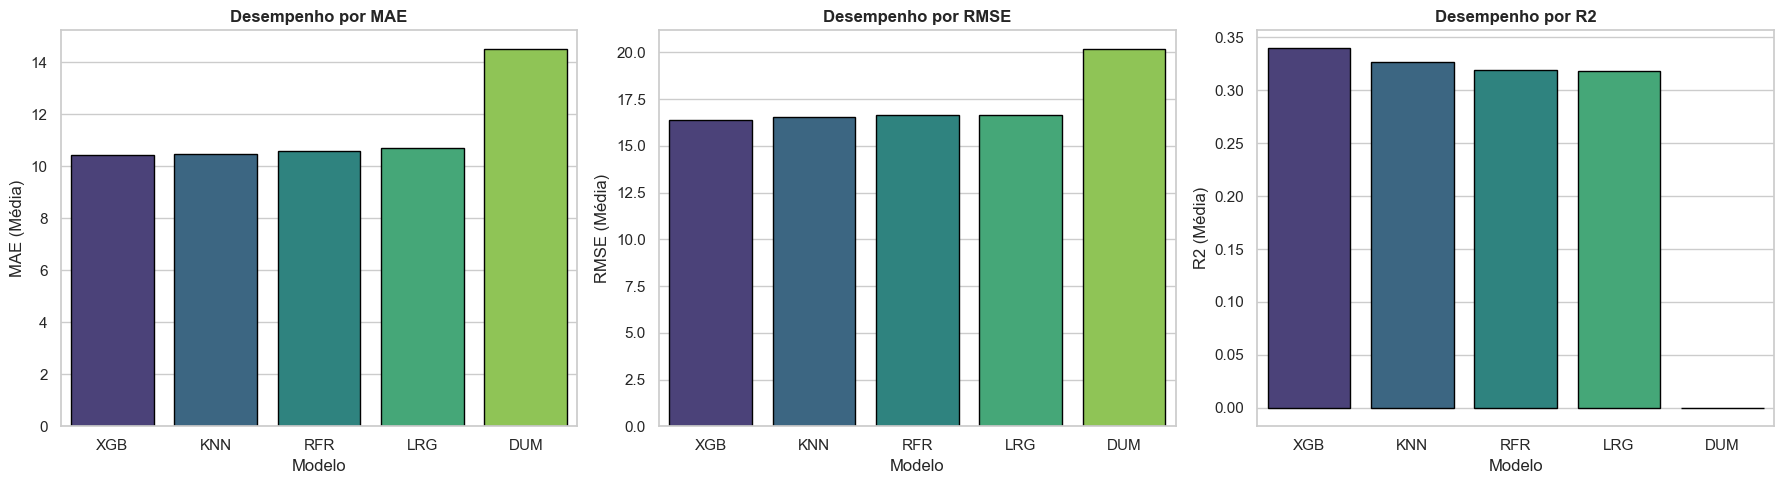

In [22]:
# Visualização do Desempenho

df_plot = final_results.copy()
df_plot = df_plot.rename(columns={f"test_{name}": name for name in metrics.keys()}).drop(columns=['fit_time', 'score_time'])
for m in ['MAE', 'RMSE']: 
    df_plot[m] = df_plot[m].abs()
    
df_grouped = df_plot.groupby('modelo').agg(['mean', 'std']).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

metrics_to_plot = ['MAE', 'RMSE', 'R2']

for i, metric in enumerate(metrics_to_plot):
    if metric in ['MAE', 'RMSE']:
        df_sorted = df_grouped.sort_values(by=(metric, 'mean'), ascending=True)
    else: 
        df_sorted = df_grouped.sort_values(by=(metric, 'mean'), ascending=False)

    sns.barplot(ax=axes[i], x='modelo', y=(metric, 'mean'), data=df_sorted, palette='viridis', edgecolor='black')
    axes[i].set_title(f'Desempenho por {metric}', fontweight='bold')
    axes[i].set_ylabel(f'{metric} (Média)')
    axes[i].set_xlabel('Modelo')

plt.tight_layout()
plt.show()

### Conclusão

O pipeline de Machine Learning, combinando Validação Cruzada Aninhada (Nested CV) e Otimização Aleatória de Hiperparâmetros (RandomizedSearchCV), revelou insights definitivos sobre a operação de Delivery:

1. **O Campeão de Performance (XGBoost):** Após testarmos modelos estatísticos, baseados em distância e ensembles de árvores, o **eXtreme Gradient Boosting (XGB)** teve melhor performance. Ele entregou o menor Erro Médio Absoluto (MAE de 10,42 min), o menor RMSE (16,38) e o maior poder explicativo (R² de 0.3397). O XGBoost lidou com maestria com as interações não-lineares entre distância, turnos e modalidades.
2. **A Confirmação do "Teto da Informação":** O XGBoost conseguiu espremer o limite máximo de inteligência das features atuais. O salto de explicabilidade do atraso foi de 15% (no modelo inferencial simples do Notebook 04) para **~34%** no XGBoost. No entanto, a estabilização do R² nessa faixa prova matematicamente que os **66% restantes da variância pertencem a fatores externos**. Atingimos o teto preditivo dos dados logísticos de sistema.
3. **Viabilidade de Produção (Janela de SLA Dinâmica):** Com o modelo errando em média ~10,4 minutos, prever um tempo exato de entrega no app do cliente (ex: "chegará em 12 minutos") geraria atrito. A solução de negócio viável é utilizar a previsão do XGBoost para gerar **"Janelas Dinâmicas de Expectativa"** (ex: exibindo margens seguras de atraso dependendo da complexidade de cada rota), blindando a experiência do usuário contra quebras de SLA.